# cw_odmr_lock_in result: scan1-scan8

First runs taken after fixing the AWG CH1 issue (see `notes.md`'s SR830 section -- `*RST` was silently resetting CH1's continuous carrier off on every connection; `setup_ch1_carrier()` now re-configures it every run) -- from `D:\cw_odmr_lock_in\scan{1..8}`. These are the first valid runs showing the real dip.

Some points read as saturated (a value hit some level and stayed there for several consecutive frequency points -- an ADC/sensitivity clipping signature, not real signal, since real noise essentially never repeats bit-for-bit). `find_saturated_mask()` below flags these; they're plotted grayed out rather than dropped, so you can see where/how much of each scan is affected.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"D:\cw_odmr_lock_in"
RUN_NAMES = ["scan1", "scan2", "scan3", "scan4", "scan5", "scan6", "scan7", "scan8"]

runs = {}
for name in RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    reflected_dbm = np.load(f"{run_path}/{name}_lockin_spectrum_reflected_dbm.npy")
    freqs_ghz = freqs_hz / 1e9
    runs[name] = dict(freqs_ghz=freqs_ghz, x=x, y=y, r=np.hypot(x, y),
                       reflected_dbm=reflected_dbm)
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_ghz.min():.6f}-{freqs_ghz.max():.6f} GHz")

scan1: 137 points, 2.860250-2.873850 GHz
scan2: 130 points, 2.859750-2.872650 GHz
scan3: 133 points, 2.860725-2.873925 GHz
scan4: 116 points, 2.865825-2.877325 GHz
scan5: 136 points, 2.444725-2.458225 GHz
scan6: 129 points, 2.832600-2.845400 GHz
scan7: 123 points, 2.839600-2.851800 GHz
scan8: 122 points, 2.851450-2.863550 GHz


## Saturation detection

In [2]:
def find_saturated_mask(values, min_run=3):
    """
    Flag points that are part of a run of >= min_run consecutive
    (near-)identical values -- a stuck/saturated reading (ADC or
    sensitivity-range clipping), not real signal or noise: real noise
    essentially never repeats bit-for-bit for that many points in a row.
    Returns a boolean array, True where a point belongs to such a run.
    """
    values = np.asarray(values)
    n = len(values)
    mask = np.zeros(n, dtype=bool)
    if n == 0:
        return mask
    run_start = 0
    for i in range(1, n):
        if not np.isclose(values[i], values[i - 1], rtol=1e-9, atol=0):
            if i - run_start >= min_run:
                mask[run_start:i] = True
            run_start = i
    if n - run_start >= min_run:
        mask[run_start:] = True
    return mask


for name in RUN_NAMES:
    sat = find_saturated_mask(runs[name]["x"])
    runs[name]["saturated"] = sat
    print(f"{name}: {sat.sum()}/{len(sat)} points flagged saturated")

scan1: 0/137 points flagged saturated
scan2: 0/130 points flagged saturated
scan3: 0/133 points flagged saturated
scan4: 0/116 points flagged saturated
scan5: 0/136 points flagged saturated
scan6: 0/129 points flagged saturated
scan7: 0/123 points flagged saturated
scan8: 26/122 points flagged saturated


## Comparison: scan1 vs scan2 vs ... vs scan8 (saturated points grayed out)

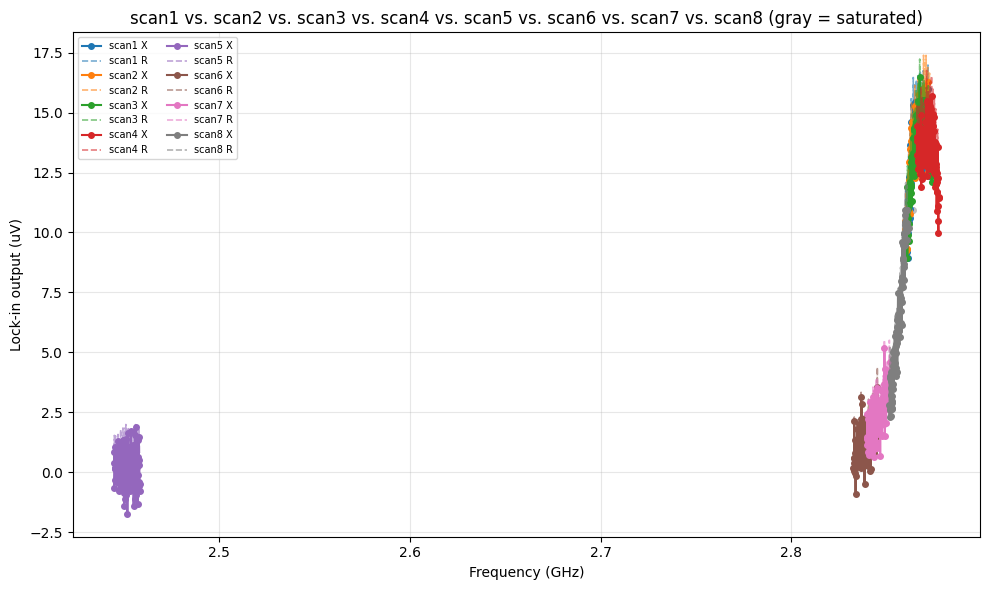

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, name in enumerate(RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs = d["freqs_ghz"]
    x_uv = d["x"] * 1e6
    r_uv = d["r"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    r_good = np.where(sat, np.nan, r_uv)
    x_bad = np.where(sat, x_uv, np.nan)
    r_bad = np.where(sat, r_uv, np.nan)

    ax.plot(freqs, x_good, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs, r_good, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")
    ax.plot(freqs, x_bad, "o", color="0.75", ms=4, zorder=1)
    ax.plot(freqs, r_bad, "--", color="0.75", lw=1.2, alpha=0.6, zorder=1)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(RUN_NAMES) + " (gray = saturated)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Zoomed comparison, scan5 excluded, frequency in MHz

`scan5` covers a completely different range (~2.4448-2.4582 GHz) from the other 7 scans (~2.833-2.878 GHz), so including it forces a wide, mostly-empty x-axis. This plot drops `scan5` and zooms into the region the remaining scans actually share, with frequency in MHz instead of GHz.

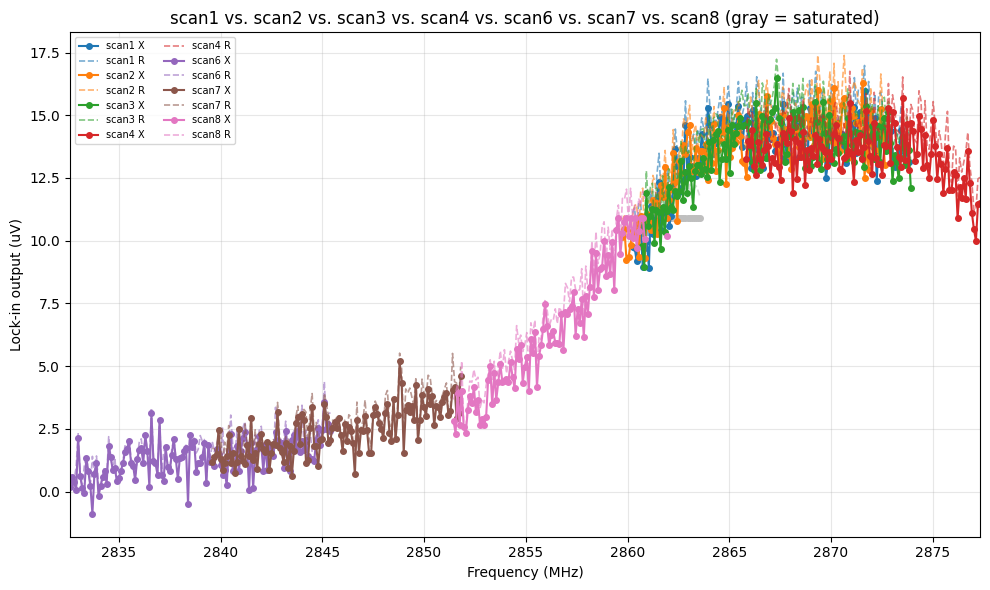

In [4]:
ZOOM_RUN_NAMES = [n for n in RUN_NAMES if n != "scan5"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6
    r_uv = d["r"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    r_good = np.where(sat, np.nan, r_uv)
    x_bad = np.where(sat, x_uv, np.nan)
    r_bad = np.where(sat, r_uv, np.nan)

    ax.plot(freqs_mhz, x_good, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs_mhz, r_good, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")
    ax.plot(freqs_mhz, x_bad, "o", color="0.75", ms=4, zorder=1)
    ax.plot(freqs_mhz, r_bad, "--", color="0.75", lw=1.2, alpha=0.6, zorder=1)

all_freqs_mhz = np.concatenate([runs[n]["freqs_ghz"] * 1e3 for n in ZOOM_RUN_NAMES])
ax.set_xlim(all_freqs_mhz.min(), all_freqs_mhz.max())
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(ZOOM_RUN_NAMES) + " (gray = saturated)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Lorentzian fit (per scan, scan5 excluded), FWHM

Fits a Lorentzian dip to each scan's X data (saturated points excluded from the fit) to extract the center frequency and FWHM.

In [5]:
from scipy.optimize import curve_fit

def lorentzian_dip(f, baseline, amplitude, center, fwhm):
    return baseline - amplitude * (fwhm / 2) ** 2 / ((f - center) ** 2 + (fwhm / 2) ** 2)


fit_results = {}
for name in ZOOM_RUN_NAMES:
    d = runs[name]
    good = ~d["saturated"]
    freqs_mhz = d["freqs_ghz"][good] * 1e3
    x_uv = d["x"][good] * 1e6

    baseline_guess = np.median(np.concatenate([x_uv[:5], x_uv[-5:]]))
    dip_idx = np.argmin(x_uv) if abs(x_uv.min() - baseline_guess) > abs(x_uv.max() - baseline_guess) \
        else np.argmax(x_uv)
    center_guess = freqs_mhz[dip_idx]
    amplitude_guess = baseline_guess - x_uv[dip_idx]
    span_mhz = freqs_mhz.max() - freqs_mhz.min()
    fwhm_guess = span_mhz / 10

    try:
        popt, pcov = curve_fit(
            lorentzian_dip, freqs_mhz, x_uv,
            p0=[baseline_guess, amplitude_guess, center_guess, fwhm_guess],
            maxfev=10000,
        )
        baseline_fit, amplitude_fit, center_fit, fwhm_fit = popt
        perr = np.sqrt(np.diag(pcov))
        fit_results[name] = dict(popt=popt, perr=perr, freqs_mhz=freqs_mhz, x_uv=x_uv)
        print(f"{name}: center = {center_fit:.4f} +/- {perr[2]:.4f} MHz, "
              f"FWHM = {abs(fwhm_fit):.4f} +/- {perr[3]:.4f} MHz")
    except RuntimeError as e:
        print(f"{name}: fit failed ({e})")

scan1: center = 2868.8168 +/- 0.2081 MHz, FWHM = 1673.6494 +/- 386183.9515 MHz
scan2: center = 2868.7839 +/- 0.3196 MHz, FWHM = 1518.0798 +/- 301014.0320 MHz
scan3: center = 2868.8469 +/- 0.1988 MHz, FWHM = 1559.4381 +/- 325220.2129 MHz
scan4: center = 2870.4236 +/- 0.3281 MHz, FWHM = 1293.3432 +/- 507690.1158 MHz
scan6: center = 2718.2704 +/- 39729.9192 MHz, FWHM = 2343.9407 +/- 9597324.1155 MHz
scan7: center = 2855.3032 +/- 11.5957 MHz, FWHM = 19.1158 +/- 19.6195 MHz
scan8: center = 2850.1597 +/- 1.8466 MHz, FWHM = 27.1222 +/- 12.6459 MHz


## Zoomed comparison with Lorentzian fits overlaid

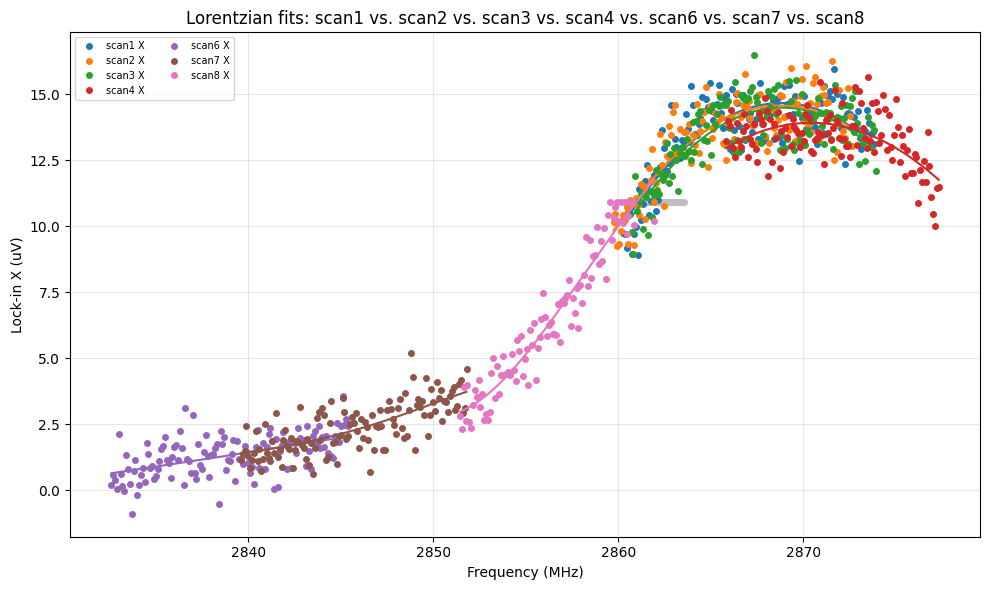

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    x_bad = np.where(sat, x_uv, np.nan)

    ax.plot(freqs_mhz, x_good, "o", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs_mhz, x_bad, "o", color="0.75", ms=4, zorder=1)

    if name in fit_results:
        fr = fit_results[name]
        f_fine = np.linspace(fr["freqs_mhz"].min(), fr["freqs_mhz"].max(), 400)
        ax.plot(f_fine, lorentzian_dip(f_fine, *fr["popt"]), "-", color=color, lw=1.5)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("Lorentzian fits: " + " vs. ".join(ZOOM_RUN_NAMES))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Combined fit: all scans except scan5, single Lorentzian

Pools every non-saturated point from all of `ZOOM_RUN_NAMES` into one dataset (sorted by frequency) and fits a single Lorentzian, instead of fitting each scan separately.

In [7]:
combined_freqs_mhz = np.concatenate([
    runs[name]["freqs_ghz"][~runs[name]["saturated"]] * 1e3
    for name in ZOOM_RUN_NAMES
])
combined_x_uv = np.concatenate([
    runs[name]["x"][~runs[name]["saturated"]] * 1e6
    for name in ZOOM_RUN_NAMES
])

order = np.argsort(combined_freqs_mhz)
combined_freqs_mhz = combined_freqs_mhz[order]
combined_x_uv = combined_x_uv[order]

print(f"{len(combined_freqs_mhz)} combined points, "
      f"{combined_freqs_mhz.min():.4f}-{combined_freqs_mhz.max():.4f} MHz")

baseline_guess = np.median(np.concatenate([combined_x_uv[:10], combined_x_uv[-10:]]))
dip_idx = np.argmin(combined_x_uv) if abs(combined_x_uv.min() - baseline_guess) > abs(combined_x_uv.max() - baseline_guess) \
    else np.argmax(combined_x_uv)
center_guess = combined_freqs_mhz[dip_idx]
amplitude_guess = baseline_guess - combined_x_uv[dip_idx]
span_mhz = combined_freqs_mhz.max() - combined_freqs_mhz.min()
fwhm_guess = span_mhz / 10

combined_popt, combined_pcov = curve_fit(
    lorentzian_dip, combined_freqs_mhz, combined_x_uv,
    p0=[baseline_guess, amplitude_guess, center_guess, fwhm_guess],
    maxfev=20000,
)
combined_perr = np.sqrt(np.diag(combined_pcov))
baseline_fit, amplitude_fit, center_fit, fwhm_fit = combined_popt

print(f"combined fit: baseline = {baseline_fit:.4f} +/- {combined_perr[0]:.4f} uV")
print(f"combined fit: amplitude = {amplitude_fit:.4f} +/- {combined_perr[1]:.4f} uV")
print(f"combined fit: center = {center_fit:.4f} +/- {combined_perr[2]:.4f} MHz")
print(f"combined fit: FWHM = {abs(fwhm_fit):.4f} +/- {combined_perr[3]:.4f} MHz")

864 combined points, 2832.6000-2877.3250 MHz
combined fit: baseline = -1.9442 +/- 0.1571 uV
combined fit: amplitude = -16.6479 +/- 0.1451 uV
combined fit: center = 2869.2129 +/- 0.0877 MHz
combined fit: FWHM = 27.9491 +/- 0.5351 MHz


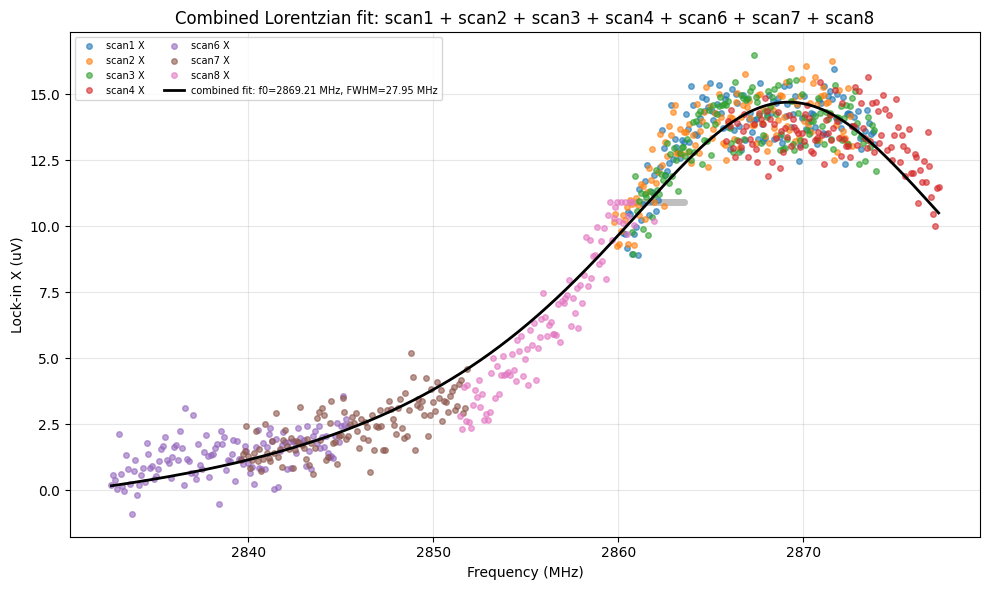

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6
    ax.plot(freqs_mhz[~sat], x_uv[~sat], "o", color=color, ms=4, alpha=0.6, label=f"{name} X")
    ax.plot(freqs_mhz[sat], x_uv[sat], "o", color="0.75", ms=4, zorder=1)

f_fine = np.linspace(combined_freqs_mhz.min(), combined_freqs_mhz.max(), 600)
ax.plot(f_fine, lorentzian_dip(f_fine, *combined_popt), "k-", lw=2,
        label=f"combined fit: f0={center_fit:.2f} MHz, FWHM={abs(fwhm_fit):.2f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("Combined Lorentzian fit: " + " + ".join(ZOOM_RUN_NAMES))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: power comparison, powerstudy4 + powerstudy5 + powerstudy6 (X, mean +/- SEM)

`powerstudy5` covers a new, non-overlapping frequency segment (~2.8666-2.8795 GHz) from `powerstudy4`'s (~2.8522-2.8639 GHz) -- combined here per power level. Repeat count is auto-detected per run (not all power levels/segments have the same number of repeats completed yet). Plotted as individual points (no connecting line) with error bars = standard error of the mean across whatever repeats are available at each point.

In [9]:
import os

def mean_sem_for_run(run_path, prefix, tag):
    """Auto-detect how many repeats exist for prefix_tag in run_path,
    load them all, and return (freqs_hz, x_mean, x_sem, n_repeats).
    Skips any repeat whose length doesn't match the expected full-sweep
    length (from freqs_hz) -- a partial repeat (interlock trip or an
    overload give-up) is saved to disk by cmd_sweep_average() but should
    be excluded from averaging, same convention as the saved _avg_*.npy
    files use."""
    freqs_hz = np.load(f"{run_path}/{prefix}_{tag}_repeat0_freqs_hz.npy")
    expected_len = len(freqs_hz)
    reps = []
    r = 0
    n_skipped = 0
    while os.path.exists(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy"):
        x_rep = np.load(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy")
        if len(x_rep) == expected_len:
            reps.append(x_rep)
        else:
            n_skipped += 1
        r += 1
    if n_skipped:
        print(f"  ({prefix}_{tag}: skipped {n_skipped} partial repeat(s))")
    x_reps = np.stack(reps)
    x_mean = x_reps.mean(axis=0)
    n = len(reps)
    x_sem = x_reps.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(x_mean)
    return freqs_hz, x_mean, x_sem, n


RUNS_TO_COMBINE = [
    (r"D:\cw_odmr_lock_in\powerstudy4", "powerstudy4"),
    (r"D:\cw_odmr_lock_in\powerstudy5", "powerstudy5"),
    (r"D:\cw_odmr_lock_in\powerstudy6", "powerstudy6"),
]
POWER_TAGS = {"0 dBm": "p0dBm", "-5 dBm": "pm5dBm", "-10 dBm": "pm10dBm"}

power_stats_combined = {}
for label, tag in POWER_TAGS.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_TO_COMBINE:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_combined[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy4 contributes 118 points, 5 repeats
0 dBm: powerstudy5 contributes 130 points, 5 repeats
0 dBm: powerstudy6 contributes 26 points, 5 repeats
-5 dBm: powerstudy4 contributes 118 points, 5 repeats
-5 dBm: powerstudy5 contributes 130 points, 5 repeats
  (powerstudy6_pm5dBm: skipped 4 partial repeat(s))
-5 dBm: powerstudy6 contributes 26 points, 1 repeats
-10 dBm: powerstudy4 contributes 118 points, 5 repeats
-10 dBm: powerstudy5 contributes 130 points, 5 repeats
-10 dBm: powerstudy6 contributes 23 points, 5 repeats


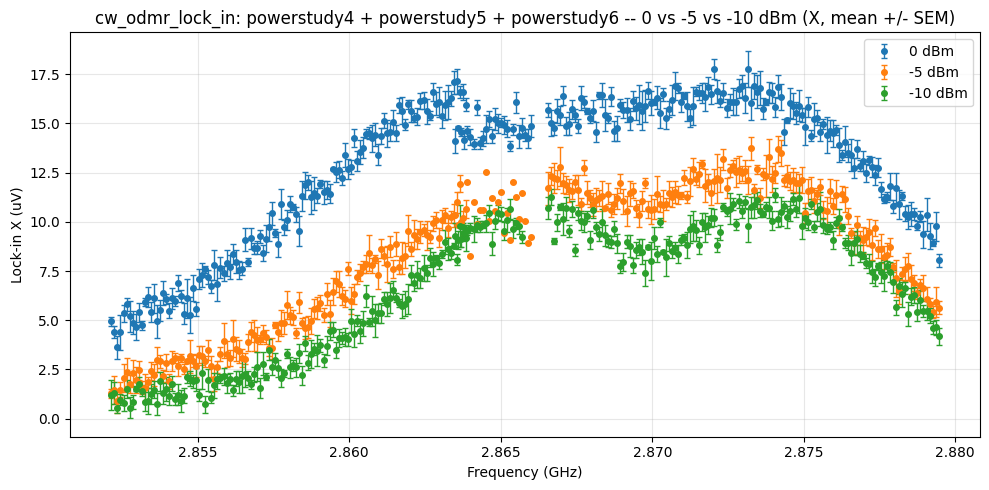

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, d in power_stats_combined.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy4 + powerstudy5 + powerstudy6 -- "
             "0 vs -5 vs -10 dBm (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerstudy8 + powerstudy9 -- all power levels

Combines `powerstudy8` (~2.8622-2.8773 GHz) and `powerstudy9` (~2.8513-2.8676 GHz) per power level -- the two segments partially overlap. Common power levels: 0, -5, -10, -15, -20 dBm (powerstudy8 also has -25 dBm, included on its own). Mean +/- SEM via `mean_sem_for_run()` (defined above), which already skips partial repeats.

In [11]:
RUNS_89 = [
    (r"D:\cw_odmr_lock_in\powerstudy8", "powerstudy8"),
    (r"D:\cw_odmr_lock_in\powerstudy9", "powerstudy9"),
]
POWER_TAGS_89 = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
    "-25 dBm": "pm25dBm",
}

power_stats_89 = {}
for label, tag in POWER_TAGS_89.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_89:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_89[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy8 contributes 152 points, 25 repeats
-5 dBm: powerstudy8 contributes 152 points, 25 repeats
-10 dBm: powerstudy8 contributes 152 points, 25 repeats
-15 dBm: powerstudy8 contributes 152 points, 25 repeats
-20 dBm: powerstudy8 contributes 152 points, 25 repeats
-25 dBm: powerstudy8 contributes 152 points, 25 repeats


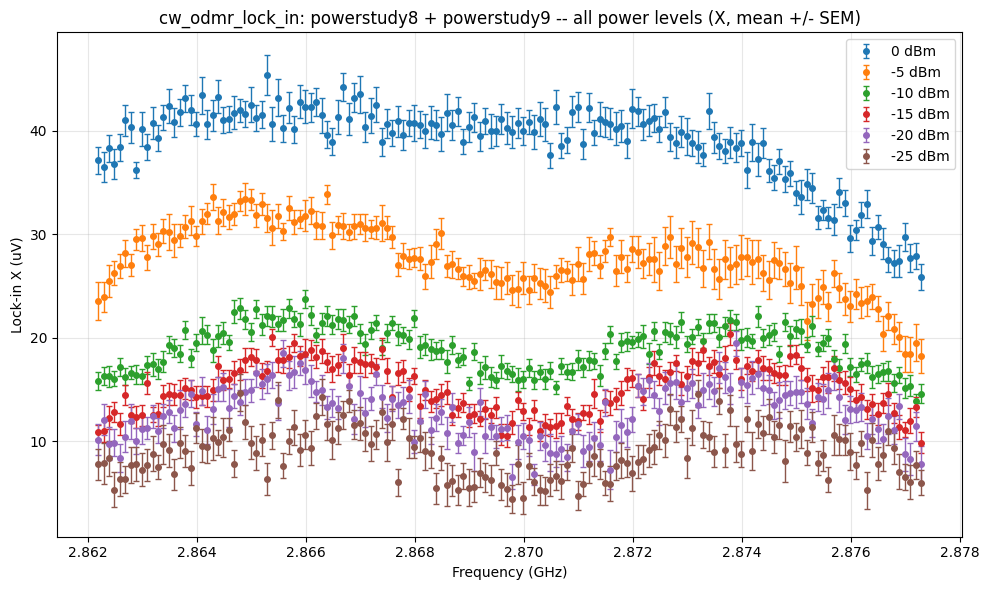

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_89.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy8 + powerstudy9 -- "
             "all power levels (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Same data, R instead of X (phase-independent check)

Testing whether the run-to-run scale differences in X are a phase-calibration artifact (X = R*cos(theta), and theta was never nulled/calibrated -- see discussion above) rather than a real change in signal size. R = sqrt(X^2+Y^2) is phase-independent, so if that's the explanation, R should look much more consistent in absolute scale across runs than X did. R is computed from the AVERAGED X/Y per repeat (not by averaging R directly), matching `cmd_sweep_average()`'s own convention to avoid R's positive noise-rectification bias; R's error bar is propagated from X/Y's SEM via standard error propagation for R = sqrt(X^2+Y^2): sigma_R = sqrt((X/R*sigma_X)^2 + (Y/R*sigma_Y)^2).

In [13]:
def mean_sem_r_for_run(run_path, prefix, tag):
    freqs_hz = np.load(f"{run_path}/{prefix}_{tag}_repeat0_freqs_hz.npy")
    expected_len = len(freqs_hz)
    x_reps, y_reps = [], []
    r = 0
    n_skipped = 0
    while os.path.exists(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy"):
        x_rep = np.load(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy")
        y_rep = np.load(f"{run_path}/{prefix}_{tag}_repeat{r}_y.npy")
        if len(x_rep) == expected_len:
            x_reps.append(x_rep)
            y_reps.append(y_rep)
        else:
            n_skipped += 1
        r += 1
    if n_skipped:
        print(f"  ({prefix}_{tag}: skipped {n_skipped} partial repeat(s))")
    x_arr = np.stack(x_reps)
    y_arr = np.stack(y_reps)
    n = len(x_reps)
    x_mean = x_arr.mean(axis=0)
    y_mean = y_arr.mean(axis=0)
    r_mean = np.hypot(x_mean, y_mean)
    if n > 1:
        x_sem = x_arr.std(axis=0, ddof=1) / np.sqrt(n)
        y_sem = y_arr.std(axis=0, ddof=1) / np.sqrt(n)
        with np.errstate(invalid="ignore", divide="ignore"):
            r_sem = np.sqrt((x_mean / r_mean * x_sem) ** 2
                            + (y_mean / r_mean * y_sem) ** 2)
        r_sem = np.nan_to_num(r_sem)
    else:
        r_sem = np.zeros_like(r_mean)
    return freqs_hz, r_mean, r_sem, n


r_stats_89 = {}
for label, tag in POWER_TAGS_89.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_89:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, r_mean, r_sem, n = mean_sem_r_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(r_mean)
        sem_list.append(r_sem)
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    r_mean_all = np.concatenate(mean_list)
    r_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    r_stats_89[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        r_mean=r_mean_all[order],
        r_sem=r_sem_all[order],
    )

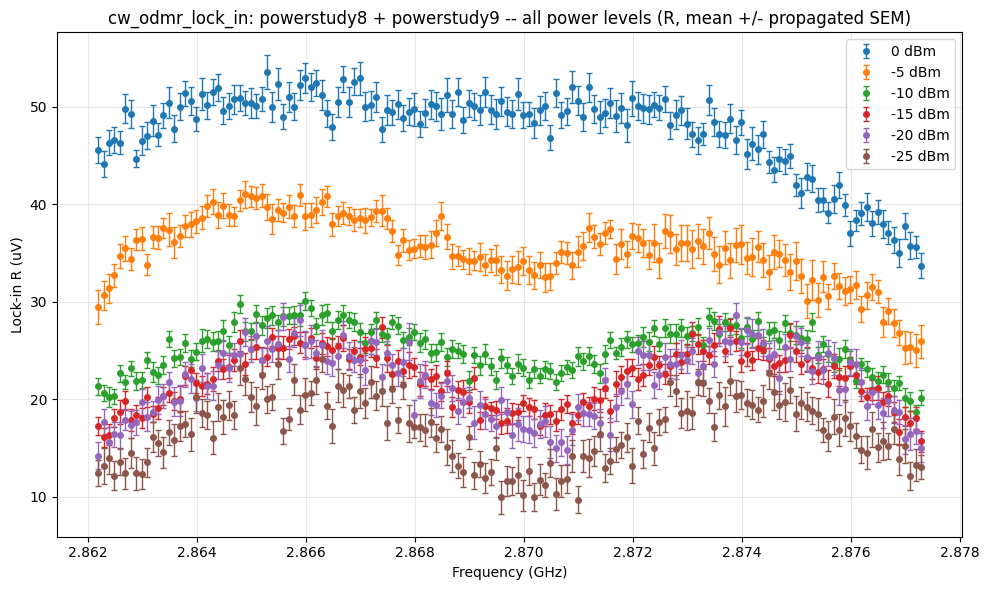

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in r_stats_89.items():
    ax.errorbar(d["freqs_ghz"], d["r_mean"] * 1e6, yerr=d["r_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy8 + powerstudy9 -- "
             "all power levels (R, mean +/- propagated SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerstudy8 + powerstudy10 + powerstudy11 -- all power levels

Combines `powerstudy8`, `powerstudy10`, and `powerstudy11` per power level (same convention as the `powerstudy8` + `powerstudy9` section above, using `mean_sem_for_run()` defined there). Common power levels: 0, -5, -10, -15, -20 dBm (powerstudy8 and powerstudy10 also have -25 dBm; powerstudy11 does not, so it just doesn't contribute a segment there).

In [15]:
RUNS_8_10_11 = [
    (r"D:\cw_odmr_lock_in\powerstudy8", "powerstudy8"),
    (r"D:\cw_odmr_lock_in\powerstudy10", "powerstudy10"),
    (r"D:\cw_odmr_lock_in\powerstudy11", "powerstudy11"),
]
POWER_TAGS_8_10_11 = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
    "-25 dBm": "pm25dBm",
}

power_stats_8_10_11 = {}
for label, tag in POWER_TAGS_8_10_11.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_8_10_11:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_8_10_11[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy8 contributes 152 points, 25 repeats
0 dBm: powerstudy10 contributes 149 points, 5 repeats
0 dBm: powerstudy11 contributes 143 points, 5 repeats
-5 dBm: powerstudy8 contributes 152 points, 25 repeats
-5 dBm: powerstudy10 contributes 149 points, 5 repeats
-5 dBm: powerstudy11 contributes 143 points, 5 repeats
-10 dBm: powerstudy8 contributes 152 points, 25 repeats
-10 dBm: powerstudy10 contributes 149 points, 5 repeats
-10 dBm: powerstudy11 contributes 143 points, 5 repeats
-15 dBm: powerstudy8 contributes 152 points, 25 repeats
-15 dBm: powerstudy10 contributes 149 points, 5 repeats
-15 dBm: powerstudy11 contributes 143 points, 5 repeats
-20 dBm: powerstudy8 contributes 152 points, 25 repeats
-20 dBm: powerstudy10 contributes 149 points, 5 repeats
-20 dBm: powerstudy11 contributes 143 points, 5 repeats
-25 dBm: powerstudy8 contributes 152 points, 25 repeats
-25 dBm: powerstudy10 contributes 149 points, 5 repeats


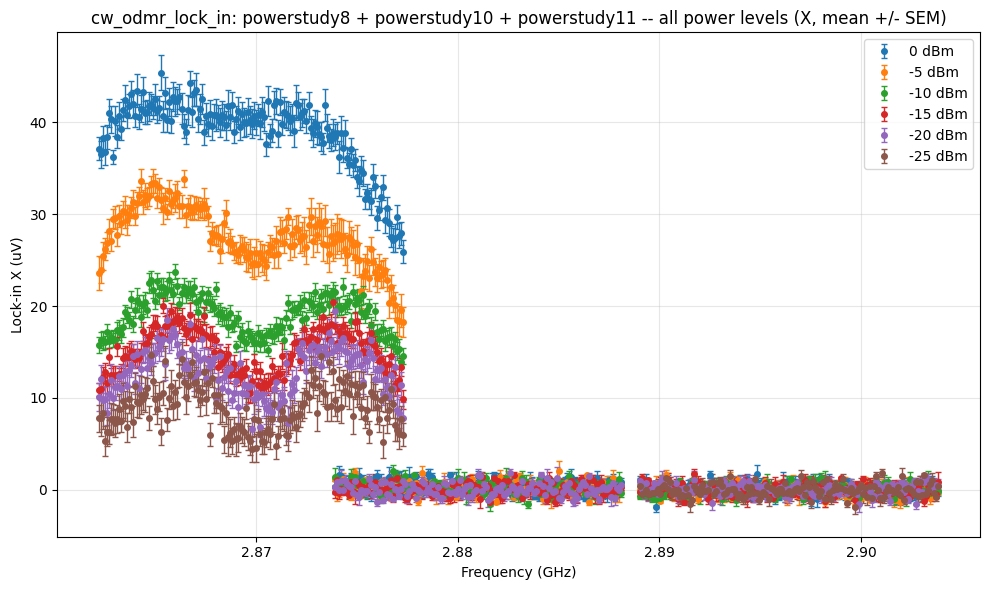

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_8_10_11.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy8 + powerstudy10 + powerstudy11 -- "
             "all power levels (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerscan1 + powerscan2 + powerscan3 + powerscan4 -- all power levels

Combines `powerscan1` (~2.8677-2.8812 GHz), `powerscan2` (~2.8445-2.8565 GHz), `powerscan3` (~2.8521-2.8657 GHz, slightly overlapping `powerscan2`), and `powerscan4` (~2.865-2.870 GHz, overlapping `powerscan1`) per power level -- same convention as the `powerstudy` combination sections above (`mean_sem_for_run()`, segments concatenated and sorted by frequency). Common power levels: 0, -5, -10, -15, -20 dBm. Only 1 repeat per run/power level, so error bars are all-zero.

In [17]:
RUNS_PS1_PS2_PS3_PS4 = [
    (r"D:\cw_odmr_lock_in\powerscan1", "powerscan1"),
    (r"D:\cw_odmr_lock_in\powerscan2", "powerscan2"),
    (r"D:\cw_odmr_lock_in\powerscan3", "powerscan3"),
    (r"D:\cw_odmr_lock_in\powerscan4", "powerscan4"),
]
POWER_TAGS_PS1_PS2_PS3_PS4 = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
}

power_stats_ps1_ps2_ps3_ps4 = {}
for label, tag in POWER_TAGS_PS1_PS2_PS3_PS4.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_PS1_PS2_PS3_PS4:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_ps1_ps2_ps3_ps4[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerscan1 contributes 136 points, 1 repeats
0 dBm: powerscan2 contributes 121 points, 1 repeats
0 dBm: powerscan3 contributes 137 points, 1 repeats
0 dBm: powerscan4 contributes 51 points, 1 repeats
-5 dBm: powerscan1 contributes 136 points, 1 repeats
-5 dBm: powerscan2 contributes 121 points, 1 repeats
-5 dBm: powerscan3 contributes 137 points, 1 repeats
-5 dBm: powerscan4 contributes 51 points, 1 repeats
-10 dBm: powerscan1 contributes 136 points, 1 repeats
-10 dBm: powerscan2 contributes 121 points, 1 repeats
-10 dBm: powerscan3 contributes 137 points, 1 repeats
-10 dBm: powerscan4 contributes 51 points, 1 repeats
-15 dBm: powerscan1 contributes 136 points, 1 repeats
-15 dBm: powerscan2 contributes 121 points, 1 repeats
-15 dBm: powerscan3 contributes 137 points, 1 repeats
-15 dBm: powerscan4 contributes 51 points, 1 repeats
-20 dBm: powerscan1 contributes 136 points, 1 repeats
-20 dBm: powerscan2 contributes 121 points, 1 repeats
-20 dBm: powerscan3 contributes 137 points, 

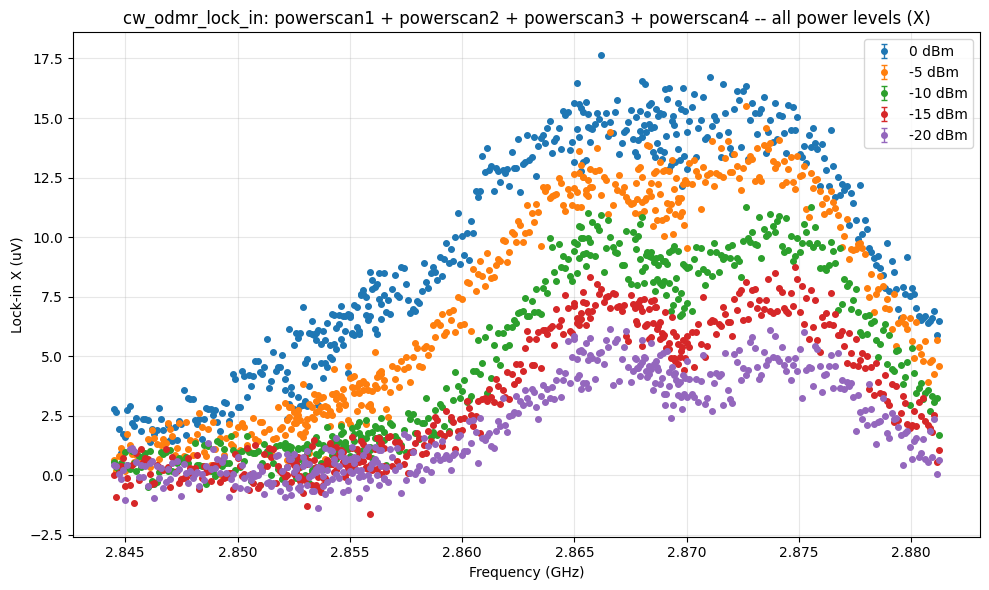

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_ps1_ps2_ps3_ps4.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerscan1 + powerscan2 + powerscan3 + powerscan4 -- "
             "all power levels (X)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()